In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
! pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tongpython/cat-and-dog")

In [12]:
train_datagen = ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
traing_set=train_datagen.flow_from_directory('/content/cat-and-dog/training_set',target_size=(64,64),
                                              batch_size=16,class_mode='binary')

Found 8005 images belonging to 1 classes.


In [14]:
train_datagen = ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_set=train_datagen.flow_from_directory('/content/cat-and-dog/test_set',target_size=(64,64),
                                              batch_size=16,class_mode='binary')

Found 2023 images belonging to 1 classes.


In [15]:
cnn=tf.keras.models.Sequential()

In [17]:
#convolution
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape=(64,64,3)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
#pooling
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [19]:
#add 2nd convolution layer
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape=(64,64,3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
#flattening
cnn.add(tf.keras.layers.Flatten())


In [22]:
#full connection
cnn.add(tf.keras.layers.Dense(units=128,activation='relu'))

In [23]:
#output layer
cnn.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))


In [24]:
#complile cnn
cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
cnn.fit(x=traing_set,validation_data=test_set,epochs=25)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


501/501 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 4.1719e-13
Epoch 2/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 1.0000 - loss: 1.5478e-11 - val_accuracy: 1.0000 - val_loss: 1.0907e-12
Epoch 3/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 1.0000 - loss: 1.1676e-11 - val_accuracy: 1.0000 - val_loss: 1.3364e-12
Epoch 4/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 1.0000 - loss: 6.3542e-12 - val_accuracy: 1.0000 - val_loss: 1.3444e-12
Epoch 5/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 1.0000 - loss: 3.8093e-11 - val_accuracy: 1.0000 - val_loss: 7.1613e-13
Epoch 6/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 1.0000 - loss: 4.7361e-11 - val_accuracy: 1.0000 - val_loss: 1.6544e-11
Epoch 7/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 1.0000 - loss: 4.9389e-12 - val_accuracy: 1.0000 - val_loss: 1.9076e-12
Epoch 8/25
501/501 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/

In [31]:
#lenet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

def LeNet(input_shape=(64,64,3), num_classes=1):
    model = Sequential()

    model.add(Conv2D(6, (5,5), activation='tanh', input_shape=input_shape))
    model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(Conv2D(16, (5,5), activation='tanh'))
    model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(Flatten())
    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))
    model.add(Dense(num_classes, activation='sigmoid')) # Changed activation to sigmoid for binary classification

    return model

model = LeNet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Changed loss to binary_crossentropy

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
letnet = model.fit(
    x=traing_set,
    epochs=10,
    validation_data=test_set
)

Epoch 1/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - accuracy: 0.9907 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 2.0106e-05
Epoch 2/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 1.0000 - loss: 1.6415e-05 - val_accuracy: 1.0000 - val_loss: 9.8406e-06
Epoch 3/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 1.0000 - loss: 8.7571e-06 - val_accuracy: 1.0000 - val_loss: 6.1605e-06
Epoch 4/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 1.0000 - loss: 5.6059e-06 - val_accuracy: 1.0000 - val_loss: 4.2411e-06
Epoch 5/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 1.0000 - loss: 3.9170e-06 - val_accuracy: 1.0000 - val_loss: 3.0816e-06
Epoch 6/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 1.0000 - loss: 2.8671e-06 - val_accuracy: 1.0000 - val_loss: 2.3125e-06
Epoch 7/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 1.0000 - loss: 2.1672e-06 - val_accuracy: 1.0000 - val_loss: 1.7673e-06
Epoch 8/10
501/501 ━━━━━━━━━━━━━━━━━━━

In [34]:
loss, acc = model.evaluate(test_set)
print("Test Accuracy:", acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 1.0000 - loss: 8.2614e-07
Test Accuracy: 1.0


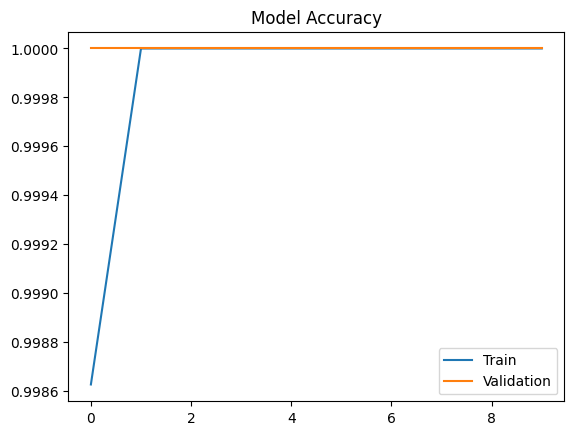

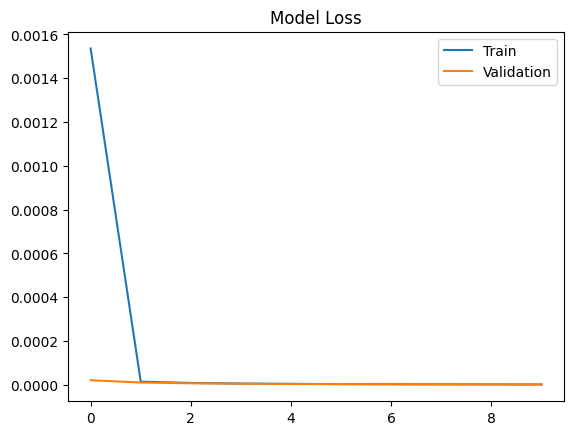

In [36]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(letnet.history['accuracy'])
plt.plot(letnet.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(letnet.history['loss'])
plt.plot(letnet.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [37]:
#alexnet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def AlexNet(input_shape=(224,224,3), num_classes=1000):
    model = Sequential()

    model.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(3,3), strides=2))

    model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3,3), strides=2))

    model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(3,3), strides=2))

    model.add(Flatten())
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [40]:
letnet = model.fit(
    x=traing_set,
    epochs=10,
    validation_data=test_set
)

Epoch 1/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 1.0000 - loss: 6.8505e-08 - val_accuracy: 1.0000 - val_loss: 5.7021e-08
Epoch 2/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 1.0000 - loss: 5.3819e-08 - val_accuracy: 1.0000 - val_loss: 4.4821e-08
Epoch 3/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 1.0000 - loss: 4.2281e-08 - val_accuracy: 1.0000 - val_loss: 3.5261e-08
Epoch 4/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 1.0000 - loss: 3.3271e-08 - val_accuracy: 1.0000 - val_loss: 2.7781e-08
Epoch 5/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 1.0000 - loss: 2.6211e-08 - val_accuracy: 1.0000 - val_loss: 2.1915e-08
Epoch 6/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 1.0000 - loss: 2.0696e-08 - val_accuracy: 1.0000 - val_loss: 1.7329e-08
Epoch 7/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 1.0000 - loss: 1.6369e-08 - val_accuracy: 1.0000 - val_loss: 1.3732e-08
Epoch 8/10
501/501 ━━━━━━━━━━━━━━━

In [41]:
loss, acc = model.evaluate(test_set)
print("Test Accuracy:", acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 1.0000 - loss: 6.9735e-09
Test Accuracy: 1.0


In [44]:
#VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def VGG16(input_shape=(224,224,3), num_classes=1000):
    model = Sequential()

    # Block 1
    model.add(Conv2D(64, (3,3), padding='same', activation='relu', input_shape=input_shape))
    model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2,2)))

    # Block 2
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2,2)))

    # Block 3
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(4096, activation='relu'))
    model.add(Dense(4096, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [45]:
loss, acc = model.evaluate(test_set)
print("Test Accuracy:", acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 1.0000 - loss: 6.9771e-09
Test Accuracy: 1.0


In [43]:
#resnet
from tensorflow.keras.layers import Input, Conv2D, Add, ReLU
from tensorflow.keras.models import Model

def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = ReLU()(x)

    x = Conv2D(filters, (3,3), padding='same')(x)

    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

def SimpleResNet(input_shape=(64,64,3), num_classes=10):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='same')(inputs)
    x = ReLU()(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = Flatten()(x)
    x = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, x)

In [ ]:
loss, acc = model.evaluate(test_set)
print("Test Accuracy:", acc)

In [46]:
#inception
from tensorflow.keras.layers import Concatenate

def inception_module(x, filters):
    conv1 = Conv2D(filters, (1,1), padding='same', activation='relu')(x)

    conv3 = Conv2D(filters, (3,3), padding='same', activation='relu')(x)

    conv5 = Conv2D(filters, (5,5), padding='same', activation='relu')(x)

    output = Concatenate()([conv1, conv3, conv5])
    return output

def SimpleInception(input_shape=(64,64,3), num_classes=10):
    inputs = Input(shape=input_shape)

    x = inception_module(inputs, 32)
    x = inception_module(x, 64)

    x = Flatten()(x)
    x = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, x)
